<a href="https://colab.research.google.com/github/imsumedhaa/fireducks-vs-pandas-EDA/blob/main/EDA_%26_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install fireducks

import pandas as pd
import fireducks.pandas as fd
import numpy as np

df = pd.DataFrame({
    "product": np.random.choice(["apple", "banana", "orange", "kiwi"], size=10_000_000),
    "region": np.random.choice(["north", "south", "east", "west"], size=10_000_000),
    "price": np.random.uniform(5, 200, size=10_000_000),
    "units_sold": np.random.randint(1, 100, size=10_000_000)
})
df.to_csv("sales_data.csv", index=False)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 MB 12.0 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0


In [ ]:
#Load Data

import time

start = time.time()
df_pd = pd.read_csv("sales_data.csv")
print("Pandas Load Time:", round(time.time() - start, 2))

start = time.time()
df_fd = fd.read_csv("sales_data.csv")
print("FireDucks Load Time:", round(time.time() - start, 2))

Pandas Load Time: 6.65
FireDucks Load Time: 0.02


In [ ]:
#Filtering and Grouping

def evaluate(df):
    try:
        df._evaluate()  # FireDucks only
    except AttributeError:
        pass  # Pandas fallback

# --- Pandas ---
start = time.time()
filtered_pd = df_pd[df_pd['price'] > 100]
grouped_pd = filtered_pd.groupby('region')['units_sold'].mean()
print("📊 Pandas GroupBy Time:", round(time.time() - start, 4), "seconds")

# --- FireDucks ---
start = time.time()
filtered_fd = df_fd[df_fd['price'] > 100]
grouped_fd = filtered_fd.groupby('region')['units_sold'].mean()
evaluate(grouped_fd)
print("🔥 FireDucks GroupBy Time:", round(time.time() - start, 4), "seconds")


📊 Pandas GroupBy Time: 1.9642 seconds
🔥 FireDucks GroupBy Time: 0.9991 seconds


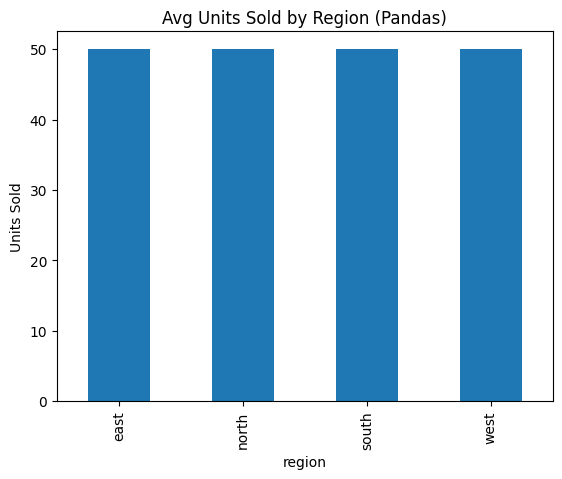

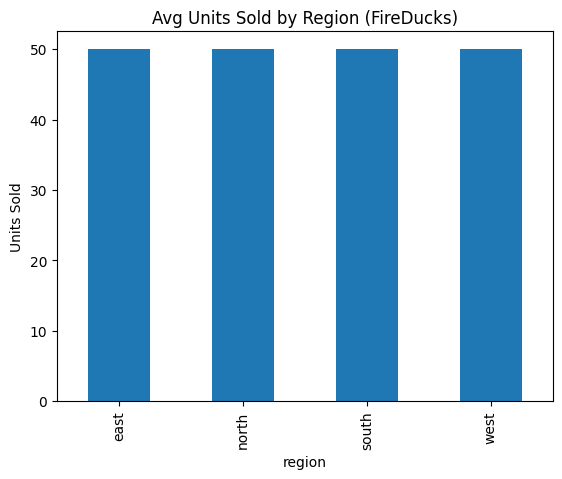

In [ ]:
#Visualization

import matplotlib.pyplot as plt

grouped_pd.plot(kind='bar', title="Avg Units Sold by Region (Pandas)")
plt.ylabel("Units Sold")
plt.show()

grouped_fd.plot(kind='bar', title="Avg Units Sold by Region (FireDucks)")
plt.ylabel("Units Sold")
plt.show()